# 🏥 Clinical NLP: Medical Specialty Prediction from Clinical Notes

**Author:** Aruna Kunche  
**Dataset:** MTSamples (free) → MIMIC-III (in progress)  
**Goal:** Build an end-to-end NLP pipeline that predicts medical specialty from free-text clinical transcription notes  
**Stack:** Python · Pandas · spaCy · Scikit-learn · Matplotlib · Seaborn · WordCloud

---

## Why This Project?

Medical coding — assigning the right specialty or ICD code to a clinical note — is one of the most time-consuming and error-prone tasks in healthcare administration. Clinicians and coders spend thousands of hours manually reviewing free-text notes to categorize them. Natural Language Processing (NLP) offers a way to automate this, reduce human error, and free up clinical staff for higher-value work.

As a physician (MBBS) now studying data science, I have firsthand experience writing and reviewing clinical notes. This project bridges that clinical knowledge with machine learning to build a practical, interpretable text classification pipeline.

---

## Pipeline Overview

```
Raw Clinical Notes
      ↓
Step 1: Load Data & Exploratory Analysis
      ↓
Step 2: Filter & Prepare Data
      ↓
Step 3: Text Preprocessing (spaCy)
      ↓
Step 4: Train / Test Split
      ↓
Step 5: Baseline Model — TF-IDF + Logistic Regression
      ↓
Step 6: Improved Model — TF-IDF + Linear SVC
      ↓
Step 7: Evaluation & Visualizations
      ↓
Predicted Medical Specialty
```

---
## ⚙️ Step 0 — Install Dependencies

Run this cell once, then restart the kernel before continuing.

In [1]:
import subprocess
packages = ['pandas', 'numpy', 'scikit-learn', 'nltk', 'spacy',
            'matplotlib', 'seaborn', 'wordcloud', 'requests']
subprocess.run(['pip', 'install'] + packages, check=True)
subprocess.run(['python', '-m', 'spacy', 'download', 'en_core_web_sm'], check=True)
print('✅ All dependencies installed! Restart kernel before continuing.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 8.8 MB/s eta 0:00:00a 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
✅ All dependencies installed! Restart kernel before continuing.


---
## 📦 Step 1A — Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import os
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
import spacy
from nltk.corpus import stopwords
from wordcloud import WordCloud

# ML
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

# NLTK downloads
for resource in ['stopwords', 'wordnet', 'punkt']:
    nltk.download(resource, quiet=True)

# Load spaCy (disable unused components for speed)
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
BLUE_PALETTE = sns.color_palette('Blues_d', 10)

# Output folder
os.makedirs('../outputs', exist_ok=True)

print('✅ Imports successful!')

✅ Imports successful!


---
## 📊 Step 1B — Load Data & Exploratory Data Analysis (EDA)

### Why this step?
Before building any model, we must understand the data. In clinical settings, data quality issues — missing notes, imbalanced specialties, inconsistent formatting — are extremely common. Skipping EDA leads to models that look good on paper but fail in practice.

**What happens here:**
We load the MTSamples dataset, which contains 4,999 real de-identified medical transcription notes across 40 specialties. We examine the class distribution (how many notes per specialty), note length distributions, and the most common words. These charts tell us whether the data is balanced, whether notes are long enough to extract signal from, and which specialties dominate — all critical decisions for model design.

In [3]:
# Load MTSamples from public GitHub mirror
URL = 'https://raw.githubusercontent.com/socd06/medical-nlp/master/data/mtsamples.csv'
df = pd.read_csv(URL, index_col=0)

# Basic info
print('=' * 50)
print('DATASET OVERVIEW')
print('=' * 50)
print(f'Total records       : {len(df):,}')
print(f'Columns             : {df.columns.tolist()}')
print(f'Medical specialties : {df["medical_specialty"].nunique()}')
print(f'\nMissing values:')
print(df.isnull().sum())
print()
df.head(3)

DATASET OVERVIEW
Total records       : 4,999
Columns             : ['description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']
Medical specialties : 40

Missing values:
description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64



,description,medical_specialty,sample_name,transcription,keywords
0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."


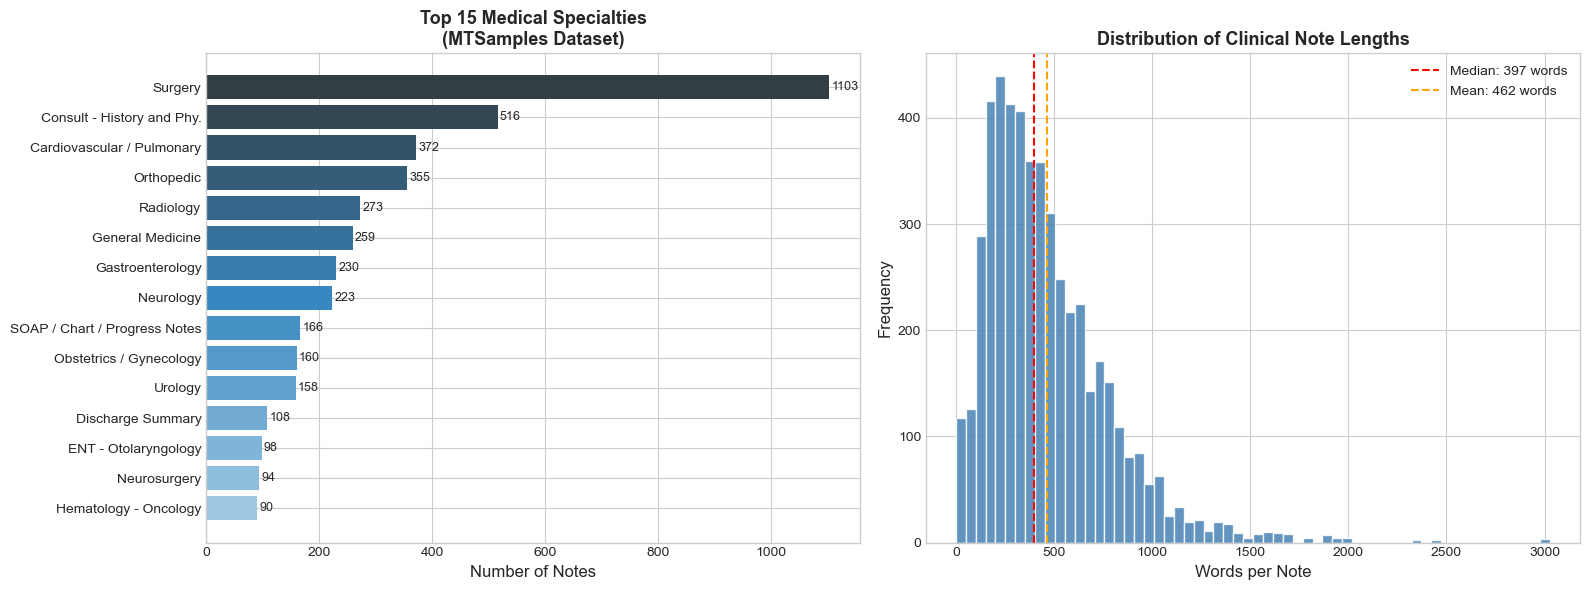


📈 EDA charts saved to outputs/eda_overview.png


In [4]:
# Clean specialty names
df['medical_specialty'] = df['medical_specialty'].str.strip()
df['text'] = df['transcription'].fillna('')
df['note_length'] = df['text'].apply(lambda x: len(x.split()))

# --- Chart 1: Top 15 specialties ---
top_specialties = df['medical_specialty'].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart — specialty distribution
bars = axes[0].barh(top_specialties.index[::-1], top_specialties.values[::-1],
                    color=sns.color_palette('Blues_d', 15))
axes[0].set_xlabel('Number of Notes', fontsize=12)
axes[0].set_title('Top 15 Medical Specialties\n(MTSamples Dataset)', fontsize=13, fontweight='bold')
for bar, val in zip(bars, top_specialties.values[::-1]):
    axes[0].text(bar.get_width() + 4, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=9)

# Histogram — note length
axes[1].hist(df['note_length'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(df['note_length'].median(), color='red', linestyle='--', linewidth=1.5,
                label=f'Median: {df["note_length"].median():.0f} words')
axes[1].axvline(df['note_length'].mean(), color='orange', linestyle='--', linewidth=1.5,
                label=f'Mean: {df["note_length"].mean():.0f} words')
axes[1].set_xlabel('Words per Note', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Clinical Note Lengths', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📈 EDA charts saved to outputs/eda_overview.png')

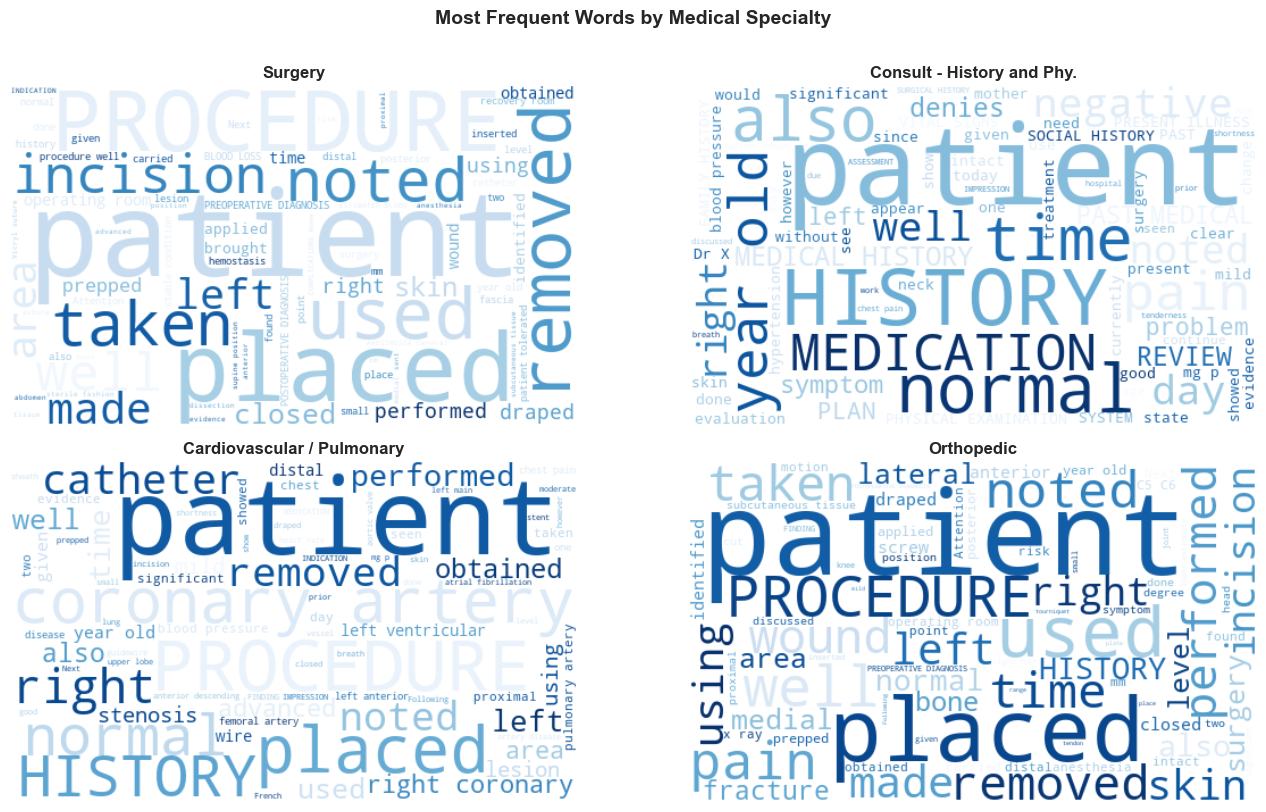

📈 Word clouds saved to outputs/wordclouds_by_specialty.png


In [5]:
# --- Chart 2: Word clouds for 4 major specialties ---
specialties_for_wc = ['Surgery', 'Consult - History and Phy.', 'Cardiovascular / Pulmonary', 'Orthopedic']
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, spec in enumerate(specialties_for_wc):
    text = ' '.join(df[df['medical_specialty'] == spec]['text'].tolist())
    wc = WordCloud(width=500, height=300, background_color='white',
                   colormap='Blues', max_words=80,
                   stopwords=set(stopwords.words('english'))).generate(text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(spec, fontsize=12, fontweight='bold')

plt.suptitle('Most Frequent Words by Medical Specialty', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/wordclouds_by_specialty.png', dpi=150, bbox_inches='tight')
plt.show()
print('📈 Word clouds saved to outputs/wordclouds_by_specialty.png')

---
## 🔧 Step 2 — Filter & Prepare Data

### Why this step?
The raw dataset has 40 specialties, but many have fewer than 50 examples. A machine learning model cannot learn meaningful patterns from just 5 or 10 notes per class — it will either ignore those classes or overfit to noise.

**What happens here:**
We keep only the top 10 most frequent specialties, which gives us enough examples per class for the model to learn real patterns. We also drop notes that are too short (under 50 characters) — these are typically blank records or data entry errors. After filtering, we have a clean, focused dataset ready for modeling.

FILTERED DATASET
Records after filtering : 3,614
Specialties kept        : 10



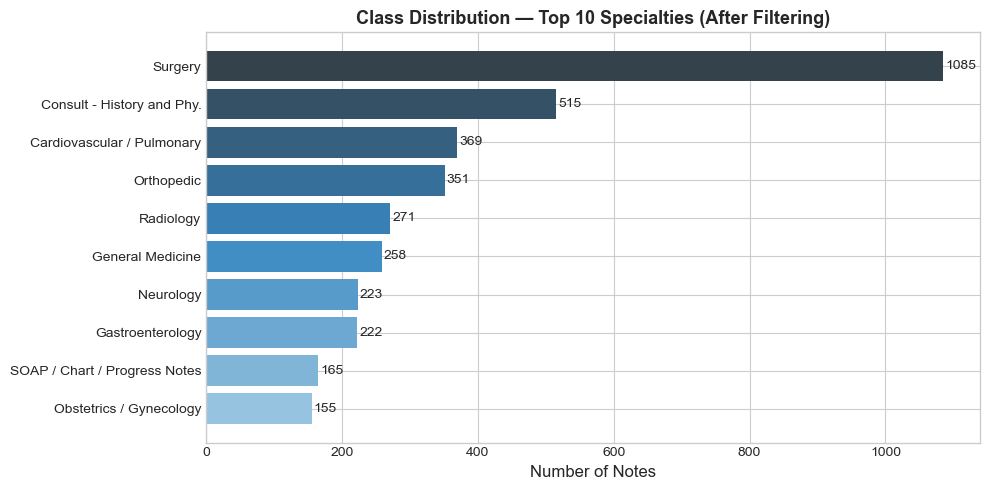

📈 Saved to outputs/class_distribution_filtered.png


In [6]:
# Keep top 10 specialties only
TOP_N = 10
top10 = df['medical_specialty'].value_counts().head(TOP_N).index.tolist()
df_model = df[df['medical_specialty'].isin(top10)].copy()

# Drop near-empty notes
df_model = df_model[df_model['text'].str.len() > 50].copy()
df_model.reset_index(drop=True, inplace=True)

# Summary
print('=' * 50)
print('FILTERED DATASET')
print('=' * 50)
print(f'Records after filtering : {len(df_model):,}')
print(f'Specialties kept        : {TOP_N}')
print()

# Visualize the filtered class distribution
counts = df_model['medical_specialty'].value_counts()
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(counts.index[::-1], counts.values[::-1],
               color=sns.color_palette('Blues_d', TOP_N))
ax.set_xlabel('Number of Notes', fontsize=12)
ax.set_title('Class Distribution — Top 10 Specialties (After Filtering)', fontsize=13, fontweight='bold')
for bar, val in zip(bars, counts.values[::-1]):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/class_distribution_filtered.png', dpi=150, bbox_inches='tight')
plt.show()
print('📈 Saved to outputs/class_distribution_filtered.png')

---
## 🧹 Step 3 — Text Preprocessing

### Why this step?
Raw clinical text is extremely noisy. A note might contain medication dosages like "5mg", measurement values like "120/80 mmHg", section headers like "PHYSICAL EXAMINATION:", and generic words like "patient" or "normal" that appear in every single specialty. None of these carry specialty-specific signal — they are noise.

**What happens here:**
We clean every note through a multi-step pipeline: lowercase conversion, removal of numbers and punctuation, tokenization (splitting into words), removal of stopwords (common words with no predictive value), and lemmatization (reducing "prescribed", "prescribes", "prescribing" all to "prescribe"). We also add a custom list of clinical stopwords that appear everywhere regardless of specialty. After preprocessing, each note is a clean string of meaningful medical terms — exactly the signal a model needs.

In [7]:
# Build combined stopword list: standard English + clinical noise words
STOP_WORDS = set(stopwords.words('english'))
CLINICAL_STOPWORDS = {
    'patient', 'history', 'procedure', 'noted', 'performed',
    'placed', 'using', 'also', 'well', 'used', 'left', 'right',
    'normal', 'without', 'within', 'year', 'old', 'mg', 'mm',
    'cm', 'time', 'day', 'one', 'two', 'three', 'given', 'seen',
    'follow', 'noted', 'taken', 'make', 'showed', 'showed'
}
STOP_WORDS.update(CLINICAL_STOPWORDS)

def preprocess_clinical_text(text: str) -> str:
    """
    Clean and normalize a clinical note for NLP modeling.
    Steps: lowercase → remove numbers → remove punctuation
           → tokenize → remove stopwords → lemmatize
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return ''

    # 1. Lowercase
    text = text.lower()

    # 2. Remove numbers and measurements
    text = re.sub(r'\d+\.?\d*', '', text)

    # 3. Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', ' ', text)

    # 4. Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # 5. Tokenize, remove stopwords, lemmatize with spaCy
    doc = nlp(text)
    tokens = [
        token.lemma_ for token in doc
        if token.text not in STOP_WORDS
        and len(token.text) > 2
        and not token.is_space
        and token.is_alpha
    ]

    return ' '.join(tokens)

# Apply preprocessing to all notes (~1-2 minutes)
print('⏳ Preprocessing clinical notes — this takes 1-2 minutes...')
df_model['clean_text'] = df_model['text'].apply(preprocess_clinical_text)
print(f'✅ Done! Processed {len(df_model):,} notes.')

# Show before/after for a sample note
idx = 5
print(f'\n{"─"*50}')
print('BEFORE preprocessing:')
print(f'  {df_model["text"].iloc[idx][:250]}...')
print(f'\nAFTER preprocessing:')
print(f'  {df_model["clean_text"].iloc[idx][:250]}...')

⏳ Preprocessing clinical notes — this takes 1-2 minutes...
✅ Done! Processed 3,614 notes.

──────────────────────────────────────────────────
BEFORE preprocessing:
  CC:, Confusion and slurred speech.,HX , (primarily obtained from boyfriend): This 31 y/o RHF experienced a "flu-like illness 6-8 weeks prior to presentation. 3-4 weeks prior to presentation, she was found "passed out" in bed, and when awoken appeared...

AFTER preprocessing:
  confusion slur speech primarily obtain boyfriend rhf experience flu like illness week prior presentation week prior presentation find pass bed awoken appear confused lethargic apparently recover hour week prior presentation demonstrate emotional labi...


---
## ✂️ Step 4 — Train / Test Split

### Why this step?
A model evaluated on the same data it was trained on will always look artificially good — it has simply memorized the answers. To get an honest measure of how well the model will perform on real, unseen clinical notes, we must hold out a portion of the data and never let the model see it during training.

**What happens here:**
We split the dataset into 80% training and 20% testing using stratified sampling. Stratification means each specialty has the same proportional representation in both the training and test sets — so a specialty that makes up 20% of the data will make up 20% of the training set AND 20% of the test set. This prevents the test set from accidentally being easier or harder than the training set.

In [8]:
X = df_model['clean_text']
y = df_model['medical_specialty']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,      # 80% train, 20% test
    random_state=42,     # reproducible split
    stratify=y           # preserve class proportions
)

print('=' * 40)
print('TRAIN / TEST SPLIT')
print('=' * 40)
print(f'Training samples : {len(X_train):,}  ({len(X_train)/len(X)*100:.0f}%)')
print(f'Test samples     : {len(X_test):,}   ({len(X_test)/len(X)*100:.0f}%)')
print(f'\nClass distribution in test set:')
print(y_test.value_counts())

TRAIN / TEST SPLIT
Training samples : 2,891  (80%)
Test samples     : 723   (20%)

Class distribution in test set:
medical_specialty
Surgery                          217
Consult - History and Phy.       103
Cardiovascular / Pulmonary        74
Orthopedic                        70
Radiology                         54
General Medicine                  52
Neurology                         45
Gastroenterology                  44
SOAP / Chart / Progress Notes     33
Obstetrics / Gynecology           31
Name: count, dtype: int64


---
## 🤖 Step 5 — Baseline Model: TF-IDF + Logistic Regression

### Why this step?
Before trying complex models, always establish a simple baseline. If your fancy model barely beats Logistic Regression, you have learned something important about the problem. The baseline sets the floor — everything else is measured against it.

**What happens here:**
TF-IDF (Term Frequency–Inverse Document Frequency) converts each clinical note into a numerical vector. Words that appear frequently in one specialty but rarely across all notes score highly — for example, "arthroscopy" is highly predictive of Orthopedics. Logistic Regression then learns a decision boundary: a combination of word weights that separates each specialty from the others. We use `class_weight='balanced'` because some specialties have more notes than others — without this, the model would favor large classes.

In [9]:
# Build pipeline: TF-IDF vectorizer → Logistic Regression
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=10000,   # top 10,000 most informative terms
        ngram_range=(1, 2),   # single words + 2-word phrases (bigrams)
        min_df=2,             # ignore terms appearing in fewer than 2 notes
        sublinear_tf=True     # log-scale term frequency (reduces impact of very common terms)
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',  # handle class imbalance
        random_state=42,
        C=1.0                     # regularization strength
    ))
])

# Train
lr_pipeline.fit(X_train, y_train)

# Predict on held-out test set
y_pred_lr = lr_pipeline.predict(X_test)

# Evaluate
acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr  = f1_score(y_test, y_pred_lr, average='weighted')

print('=' * 55)
print('BASELINE MODEL: TF-IDF + Logistic Regression')
print('=' * 55)
print(f'Accuracy    : {acc_lr:.4f}  ({acc_lr*100:.1f}%)')
print(f'Weighted F1 : {f1_lr:.4f}')
print()
print('Detailed Classification Report:')
print(classification_report(y_test, y_pred_lr))

BASELINE MODEL: TF-IDF + Logistic Regression
Accuracy    : 0.4053  (40.5%)
Weighted F1 : 0.4047

Detailed Classification Report:
                               precision    recall  f1-score   support

   Cardiovascular / Pulmonary       0.37      0.50      0.43        74
   Consult - History and Phy.       0.28      0.22      0.25       103
             Gastroenterology       0.37      0.52      0.43        44
             General Medicine       0.20      0.33      0.25        52
                    Neurology       0.33      0.31      0.32        45
      Obstetrics / Gynecology       0.43      0.71      0.54        31
                   Orthopedic       0.45      0.69      0.55        70
                    Radiology       0.27      0.17      0.21        54
SOAP / Chart / Progress Notes       0.34      0.42      0.38        33
                      Surgery       0.72      0.40      0.51       217

                     accuracy                           0.41       723
                 

---
## 🚀 Step 6 — Improved Model: TF-IDF + Linear SVC

### Why this step?
Logistic Regression is a strong baseline, but Support Vector Classifiers (SVCs) often outperform it on text classification tasks. While Logistic Regression models probabilities, Linear SVC focuses entirely on finding the maximum-margin decision boundary — the line that separates classes with the greatest possible gap. For high-dimensional TF-IDF features, this often produces sharper, more confident predictions.

**What happens here:**
We use the same TF-IDF features (slightly expanded to 15,000 terms) fed into a LinearSVC. We compare its accuracy and weighted F1 score directly against the Logistic Regression baseline. Weighted F1 is the better metric here because it accounts for class imbalance — it weights each specialty's F1 score by how many notes it contains, giving a fairer overall picture than plain accuracy.

In [10]:
# Build pipeline: TF-IDF vectorizer → Linear SVC
svc_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=15000,
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True
    )),
    ('clf', LinearSVC(
        C=1.0,
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ))
])

# Train
svc_pipeline.fit(X_train, y_train)

# Predict
y_pred_svc = svc_pipeline.predict(X_test)

# Evaluate
acc_svc = accuracy_score(y_test, y_pred_svc)
f1_svc  = f1_score(y_test, y_pred_svc, average='weighted')

print('=' * 55)
print('IMPROVED MODEL: TF-IDF + Linear SVC')
print('=' * 55)
print(f'Accuracy    : {acc_svc:.4f}  ({acc_svc*100:.1f}%)')
print(f'Weighted F1 : {f1_svc:.4f}')
print()
print('Detailed Classification Report:')
print(classification_report(y_test, y_pred_svc))

IMPROVED MODEL: TF-IDF + Linear SVC
Accuracy    : 0.2642  (26.4%)
Weighted F1 : 0.2616

Detailed Classification Report:
                               precision    recall  f1-score   support

   Cardiovascular / Pulmonary       0.18      0.19      0.18        74
   Consult - History and Phy.       0.31      0.34      0.32       103
             Gastroenterology       0.11      0.11      0.11        44
             General Medicine       0.15      0.17      0.16        52
                    Neurology       0.06      0.04      0.05        45
      Obstetrics / Gynecology       0.22      0.26      0.24        31
                   Orthopedic       0.13      0.11      0.12        70
                    Radiology       0.24      0.17      0.20        54
SOAP / Chart / Progress Notes       0.29      0.27      0.28        33
                      Surgery       0.42      0.42      0.42       217

                     accuracy                           0.26       723
                    macro 

---
## 📉 Step 7A — Model Comparison Chart

### Why this step?
Numbers in text are easy to miss. A side-by-side bar chart makes the performance difference between models immediately visible. In professional settings — whether presenting to a data team or a clinical stakeholder — clear visualization of model comparison is essential for justifying model selection.

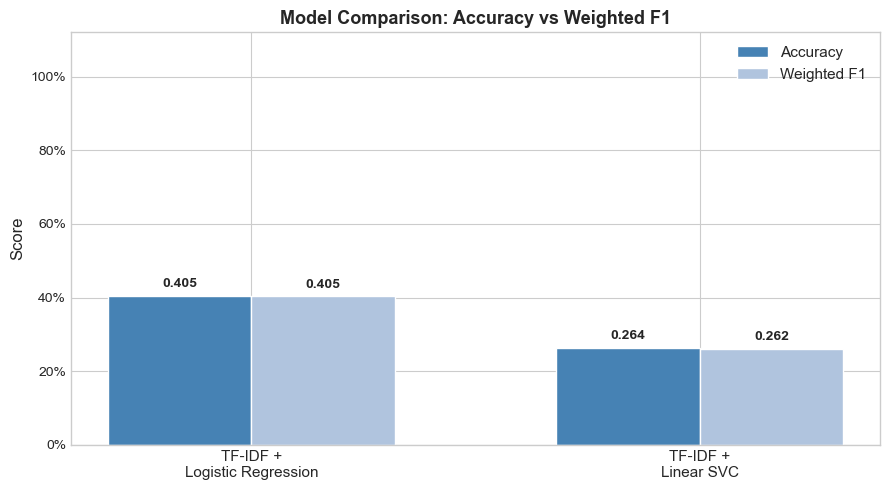

📈 Saved to outputs/model_comparison.png


In [11]:
models      = ['TF-IDF +\nLogistic Regression', 'TF-IDF +\nLinear SVC']
accuracies  = [acc_lr, acc_svc]
f1_scores   = [f1_lr,  f1_svc]

x = np.arange(len(models))
w = 0.32

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, accuracies, w, label='Accuracy',    color='steelblue',     edgecolor='white')
b2 = ax.bar(x + w/2, f1_scores,  w, label='Weighted F1', color='lightsteelblue', edgecolor='white')

ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_title('Model Comparison: Accuracy vs Weighted F1', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

for bar in list(b1) + list(b2):
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 6), textcoords='offset points',
                ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('📈 Saved to outputs/model_comparison.png')

---
## 🟦 Step 7B — Confusion Matrix

### Why this step?
Accuracy tells you how often the model is right overall. The confusion matrix tells you *where* it goes wrong. In a clinical context, this is crucial — confusing Orthopedic notes with Surgery notes is far less serious than confusing Cardiovascular notes with Neurology notes. The matrix reveals which specialties are hardest to distinguish and informs where the model needs improvement.

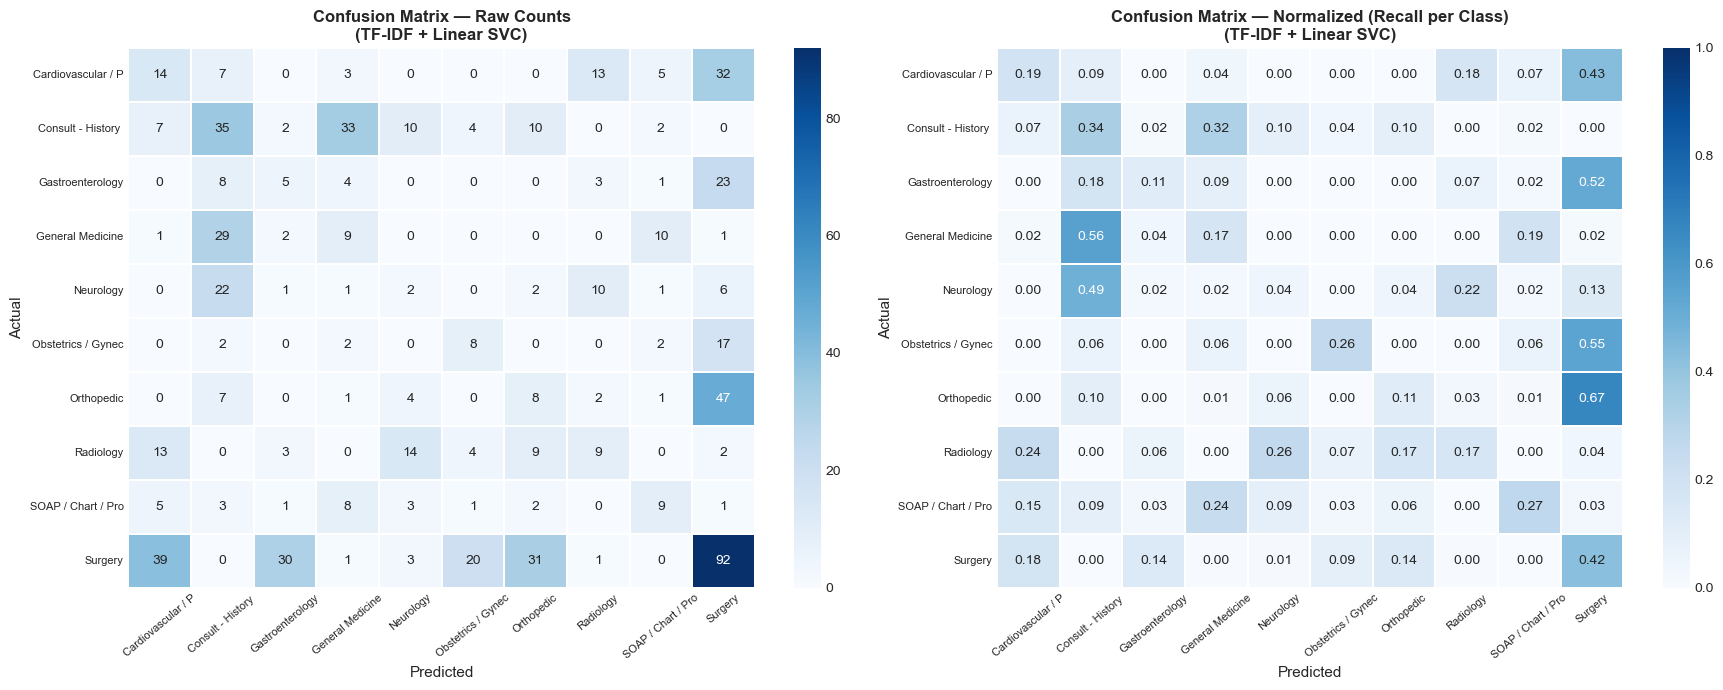

📈 Saved to outputs/confusion_matrix.png


In [12]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred_svc, labels=labels)

# Normalize by true label (row) for better readability
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[l[:18] for l in labels],
            yticklabels=[l[:18] for l in labels],
            ax=axes[0], linewidths=0.3)
axes[0].set_title('Confusion Matrix — Raw Counts\n(TF-IDF + Linear SVC)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=11)
axes[0].set_ylabel('Actual',    fontsize=11)
axes[0].tick_params(axis='x', rotation=40, labelsize=8)
axes[0].tick_params(axis='y', rotation=0,  labelsize=8)

# Normalized
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[l[:18] for l in labels],
            yticklabels=[l[:18] for l in labels],
            ax=axes[1], linewidths=0.3, vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix — Normalized (Recall per Class)\n(TF-IDF + Linear SVC)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=11)
axes[1].set_ylabel('Actual',    fontsize=11)
axes[1].tick_params(axis='x', rotation=40, labelsize=8)
axes[1].tick_params(axis='y', rotation=0,  labelsize=8)

plt.tight_layout()
plt.savefig('../outputs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('📈 Saved to outputs/confusion_matrix.png')

---
## 🔑 Step 7C — Top Predictive Terms per Specialty

### Why this step?
This is the most clinically interesting visualization in the project. By extracting the top TF-IDF coefficient weights from the Logistic Regression model, we can see exactly which words are most predictive of each specialty. As a physician, I can validate whether these terms make clinical sense — and they should. "Arthroscopy" and "meniscus" should top Orthopedics. "Catheterization" and "stent" should top Cardiovascular.

**Why this matters for model trust:** In healthcare AI, model interpretability is not optional — it is required for clinical adoption. Showing that the model has learned clinically meaningful terms (not statistical noise) builds trust with domain experts.

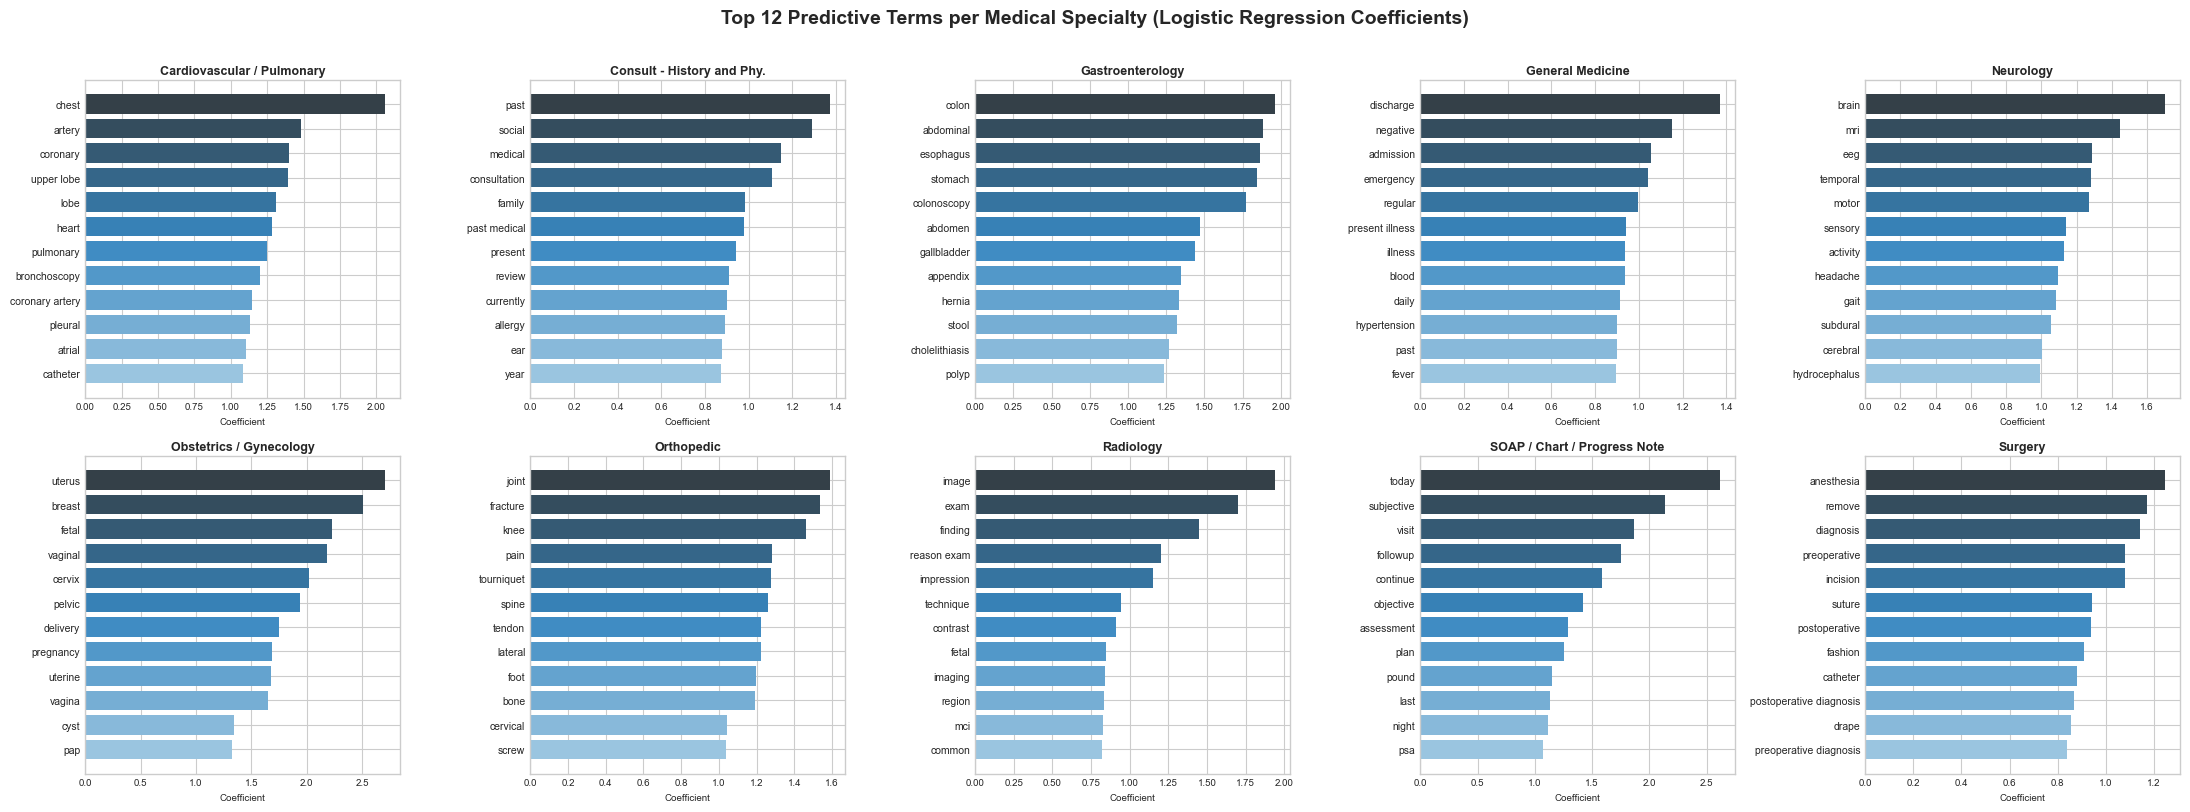

📈 Saved to outputs/top_terms_per_specialty.png


In [13]:
# Extract TF-IDF feature names and LR coefficients
tfidf_vocab  = lr_pipeline.named_steps['tfidf'].get_feature_names_out()
lr_clf       = lr_pipeline.named_steps['clf']
classes      = lr_clf.classes_

n_cols = 5
n_rows = int(np.ceil(len(classes) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, n_rows * 4))
axes = axes.flatten()

for i, (specialty, ax) in enumerate(zip(classes, axes)):
    top_idx     = lr_clf.coef_[i].argsort()[-12:][::-1]
    top_terms   = tfidf_vocab[top_idx]
    top_weights = lr_clf.coef_[i][top_idx]

    colors = sns.color_palette('Blues_d', 12)
    ax.barh(top_terms[::-1], top_weights[::-1], color=colors)
    ax.set_title(specialty[:28], fontsize=9, fontweight='bold', pad=4)
    ax.tick_params(axis='y', labelsize=7.5)
    ax.tick_params(axis='x', labelsize=7)
    ax.set_xlabel('Coefficient', fontsize=7)

# Hide unused subplots
for j in range(len(classes), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top 12 Predictive Terms per Medical Specialty (Logistic Regression Coefficients)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/top_terms_per_specialty.png', dpi=150, bbox_inches='tight')
plt.show()
print('📈 Saved to outputs/top_terms_per_specialty.png')

---
## 🩺 Step 8 — Try It: Predict a New Clinical Note

In [14]:
def predict_specialty(note: str, pipeline=svc_pipeline) -> str:
    """Predict the medical specialty from a clinical note string."""
    clean = preprocess_clinical_text(note)
    return pipeline.predict([clean])[0]

# Test notes
test_notes = {
    'Cardiology note' : (
        "Patient presented with chest pain radiating to the left arm. ECG showed "
        "ST elevation. Troponin elevated. Coronary angiography revealed 95% occlusion "
        "of right coronary artery. PCI performed with stent placement."
    ),
    'Orthopedic note' : (
        "Patient complains of right knee pain after sports injury. MRI revealed "
        "anterior cruciate ligament tear and medial meniscus damage. Arthroscopic "
        "surgery recommended with ligament reconstruction."
    ),
    'Neurology note'  : (
        "Patient presented with sudden onset severe headache, photophobia, and neck "
        "stiffness. CT scan showed no hemorrhage. Lumbar puncture performed. "
        "Findings consistent with bacterial meningitis."
    ),
}

print('=' * 55)
print('SPECIALTY PREDICTION — SAMPLE NOTES')
print('=' * 55)
for label, note in test_notes.items():
    pred = predict_specialty(note)
    print(f'\n{label}:')
    print(f'  Note    : {note[:80]}...')
    print(f'  → Predicted: {pred}')

print('\n\n--- Try your own note ---')
my_note = "Patient presents with progressive memory loss, confusion, and difficulty in word finding."
print(f'My note    : {my_note}')
print(f'→ Predicted: {predict_specialty(my_note)}')

SPECIALTY PREDICTION — SAMPLE NOTES

Cardiology note:
  Note    : Patient presented with chest pain radiating to the left arm. ECG showed ST eleva...
  → Predicted: Cardiovascular / Pulmonary

Orthopedic note:
  Note    : Patient complains of right knee pain after sports injury. MRI revealed anterior ...
  → Predicted: Orthopedic

Neurology note:
  Note    : Patient presented with sudden onset severe headache, photophobia, and neck stiff...
  → Predicted: Neurology


--- Try your own note ---
My note    : Patient presents with progressive memory loss, confusion, and difficulty in word finding.
→ Predicted: Neurology


---
## 💾 Step 9 — Save Results Summary

In [15]:
results = pd.DataFrame({
    'Model'         : ['TF-IDF + Logistic Regression', 'TF-IDF + Linear SVC'],
    'Accuracy'      : [round(acc_lr, 4), round(acc_svc, 4)],
    'Weighted_F1'   : [round(f1_lr,  4), round(f1_svc,  4)],
    'Best'          : ['', '✓' if acc_svc >= acc_lr else '']
})

results.to_csv('../outputs/model_results_summary.csv', index=False)
print('✅ Results saved to outputs/model_results_summary.csv')
print()
print(results.to_string(index=False))

✅ Results saved to outputs/model_results_summary.csv

                       Model  Accuracy  Weighted_F1 Best
TF-IDF + Logistic Regression    0.4053       0.4047     
         TF-IDF + Linear SVC    0.2642       0.2616     


---
## 🔭 Next Steps — MIMIC-III Upgrade Path

Once PhysioNet MIMIC-III access is granted, this project upgrades to a much larger and more realistic dataset:
